# Example: Let's Decompose a Synthetic Data Cloud using Singular Value Decomposition (SVD)
In this example, we generate a synthetic dataset that simulates a cloud of points in a two-dimensional space. We'll then decompose this dataset using Singular Value Decomposition (SVD) to identify the principal directions of variance in the data. 

What does SVD tell us about the structure of the data? How can we interpret the singular values and vectors in the context of this synthetic dataset? Let's find out.


> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
> 
> * __Perform singular value decomposition on data matrices:__ Apply SVD to decompose centered data into left singular vectors, singular values, and right singular vectors
> * __Interpret SVD components geometrically:__ Explain how singular values and vectors represent principal directions and variance in multidimensional datasets
> * __Connect SVD to eigendecomposition:__ Verify the mathematical relationship between singular values and eigenvalues of the covariance matrix


Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
Let's generate a synthetic dataset that simulates a cloud of points in a two-dimensional space. We'll create points that are normally distributed around the origin with some added noise. 

> __Synthetic Data Model__
> 
> We generate points from a bivariate normal distribution with mean vector $\mathbf{\mu} \in \mathbb{R}^{2}$ and covariance matrix $\mathbf{\Sigma} \in \mathbb{R}^{2 \times 2}$. The correlation parameter $\rho \in [-1, 1]$ controls the linear relationship between the two dimensions. When $\rho = 0$, the dimensions are uncorrelated; when $\rho < 0$, they are negatively correlated; and when $\rho > 0$, they are positively correlated. The covariance matrix structure $\mathbf{\Sigma} = [1.0\, \rho; \rho\, 1.0]$ ensures unit variance in each dimension while introducing the specified correlation.

We'll save the data in the `X::Array{Float64,2}` variable, where each row represents a data point in 2D space.

In [2]:
X, Σ = let

    # initialize -
    number_of_points = 25000; # TODO: number of data points to generate, update as needed

    # specify distribution parameters
    μ = [0.1, 2.0]; # mean of the distribution
    ρ = -0.5; # create some correlation between dimensions
    Σ = [1.0 ρ; ρ 1.0]; # TODO: covariance matrix, update as needed
    d = MvNormal(μ, Σ); # define the multivariate normal distribution

    # generate synthetic data
    data = rand(d, number_of_points) |> transpose |> Matrix; # generate points and transpose to get points as rows

    (data, Σ) # return the data and covariance matrix
end

([0.16031685877823276 2.0450764851366903; -0.4984222229036003 1.4891235002976004; … ; -1.7278382481677408 3.991194487027739; 0.842457468593339 1.8789318402870319], [1.0 -0.5; -0.5 1.0])

In [3]:
X

25000×2 Matrix{Float64}:
  0.160317   2.04508
 -0.498422   1.48912
  2.12542    1.58229
  0.240099   2.17895
 -0.868494   1.79382
  1.30484    1.9073
 -0.0127094  2.10265
 -1.0255     1.37335
  0.101408   2.17428
  0.29228    3.06031
  ⋮          
  0.290155   0.475726
  2.17146    1.61488
 -1.03434    2.22879
 -1.47737    2.30161
  0.620947   0.913211
 -0.311572   3.91572
  2.29082    0.849615
 -1.72784    3.99119
  0.842457   1.87893

Let's form the centered data matrix $\tilde{\mathbf{X}}$ by subtracting the mean from each row of the data matrix $\mathbf{X}$. We store the centered data in the `X_centered::Array{Float64,2}` variable:

In [4]:
X_centered = let 
    r, c = size(X)
    m = mean(X, dims=1) |> vec # mean for each dimension
    ones_vector = ones(r)
    X̃ = X .- ⊗(ones_vector, m);
end

25000×2 Matrix{Float64}:
  0.0677683    0.0384981
 -0.590971    -0.517455
  2.03287     -0.424284
  0.147551     0.172368
 -0.961042    -0.212761
  1.21229     -0.0992769
 -0.105258     0.0960756
 -1.11805     -0.633233
  0.00885995   0.167698
  0.199731     1.05373
  ⋮           
  0.197606    -1.53085
  2.07892     -0.391702
 -1.12689      0.222207
 -1.56992      0.29503
  0.528399    -1.09337
 -0.404121     1.90914
  2.19827     -1.15696
 -1.82039      1.98462
  0.749909    -0.127647

___

## Task 1: Perform SVD on the Synthetic Data Cloud
In this task, we'll perform Singular Value Decomposition (SVD) on the synthetic dataset to identify the principal directions of variance. We'll make use of [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) from Julia's standard library to do this computation.

> __How is this different from PCA via Eigendecomposition?__ While PCA typically involves computing the covariance matrix and then performing eigendecomposition, SVD directly decomposes the data matrix itself. This approach can be more efficient and numerically stable, especially for large datasets.

We'll use the [`svd(...)` method exported from the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.SVD) to compute the singular value decomposition of the synthetic dataset `X::Array{Float64,2}`.  This produces the `U`, `S`, and `V` matrices, holding the left singular vectors, the singular values, and the right singular vectors, respectively.

In [5]:
U,S,V = svd(X_centered, alg = LinearAlgebra.QRIteration(), full = true); # perform SVD on centered data matrix

What's in the `U::Array{Float64,2}`, `S::Array{Float64,1}`, and `V::Array{Float64,2}` matrices? How do they relate to the structure of our synthetic dataset? 

Let's look at each, starting with the `U::Array{Float64,2}` matrix.

> __What is in the `U::Array{Float64,2}` matrix?__ The `U` matrix contains the left singular vectors of the data matrix `X`. Each column of `U` represents a direction in the original data space along which the data varies. The left singular vectors are orthonormal, meaning they are unit vectors that are mutually perpendicular.

The `U::Array{Float64,2}` matrix will have dimension of number of samples by the number of features (2 in this case). Each column corresponds to a principal direction in the __data space__:

In [6]:
U

25000×25000 Matrix{Float64}:
 -0.000110191   0.000673911  -0.0128158    …   0.0115138    -0.00472696
  0.000302164  -0.00704149    0.00438286       0.00789002    0.00182934
 -0.00902948    0.0100955     0.999817         0.000113468  -6.84262e-5
  8.10492e-5    0.00203476   -1.9731e-5       -3.56017e-6   -7.66049e-6
  0.0027704    -0.00742162    9.96433e-5      -2.96429e-5    3.78295e-5
 -0.00482738    0.00700565   -0.000114028  …   5.87394e-5   -4.28441e-5
  0.000736152  -4.77945e-5    7.12572e-6      -1.01779e-5    2.56031e-6
  0.00182489   -0.011106      0.000128161     -1.2091e-5     4.91244e-5
  0.000575222   0.00113057   -6.17719e-6      -9.34958e-6   -2.54642e-6
  0.00308352    0.00801205   -5.2739e-5       -5.2453e-5    -2.12482e-5
  ⋮                                        ⋱                
 -0.00627727   -0.00856509    2.94714e-5       9.75184e-5    1.31009e-5
 -0.00908105    0.0105945    -0.000188516      0.000113588  -7.05354e-5
  0.00495827   -0.00567951    0.000101873     

How about the `V::Array{Float64,2}` matrix?

> __What is in the `V::Array{Float64,2}` matrix?__ The `V` matrix contains the right singular vectors of the data matrix `X`. Each column of `V` represents a direction in the feature space along which the data varies. Similar to `U`, the right singular vectors are also orthonormal.

The `V::Array{Float64,2}` matrix will have dimension of number of features by number of features (2 in this case). Each column corresponds to a principal direction in the __feature space__:

In [7]:
V

2×2 adjoint(::Matrix{Float64}) with eltype Float64:
 -0.712923  0.701242
  0.701242  0.712923

Finally, what about the `S::Array{Float64,1}` vector?

> __What is in the `S::Array{Float64,1}` vector?__ The `S` vector contains the singular values of the data matrix `X`. These values are non-negative and are typically arranged in descending order. Each singular value indicates the amount of variance captured along the corresponding singular vector directions in `U` and `V`.

What are the singular values?

In [14]:
S

2-element Vector{Float64}:
 193.45615750859696
 111.24338545744425


### Relationship between Singular Values and Eigenvalues
An obvious question to ask is: How are singular values related to eigenvalues?

> __Relationship between Singular Values and Eigenvalues:__ The singular values in `S` are related to the eigenvalues of the covariance matrix of the data. Specifically, if we compute the covariance matrix $\hat{\mathbf{\Sigma}} = \frac{1}{n-1} \tilde{\mathbf{X}}^{\top} \tilde{\mathbf{X}}$, where $n$ is the number of samples, the eigenvalues of $\hat{\mathbf{\Sigma}}$ are equal to the squares of the singular values divided by $(n-1)$. Thus, if $\sigma_i$ is a singular value, then the corresponding eigenvalue $\lambda_i$ of the covariance matrix is given by $\lambda_i = \frac{\sigma_i^2}{n-1}$.

Let's test out this claim. We can estimate the covariance matrix from the synthetic dataset `X::Array{Float64,2}` using the [`cov(...)` function from the `Statistics.jl` package](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov). Then, we can compute the eigenvalues of the covariance matrix using the [`eigen(...)` function from the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.eigen).

First, let's compute the empirical covariance matrix $\hat{\mathbf{\Sigma}}$ and store it in the `Σ̂::Array{Float64,2}` variable:

In [15]:
Σ̂ = let 

    # initialize -
    (r,c) = size(X_centered)
    Σ = (1/(r-1)) * (X_centered' * X_centered)
    Σ; # return the empirical covariance matrix
end

2×2 Matrix{Float64}:
  1.00432   -0.500956
 -0.500956   0.987771

__Is our covariance matrix estimate close?__ In this case (since we generated the data ourselves), we can compare our empirical covariance matrix estimate `Σ̂::Array{Float64,2}` to the true covariance matrix `Σ::Array{Float64,2}` used to generate the synthetic data. 

> __Test:__ We'll compare the two covariance matrices by computing the Frobenius norm of their difference. The Frobenius norm of a matrix $\mathbf{A} \in \mathbb{R}^{n \times m}$ is defined as:
> $$
\|\mathbf{A}\|_{F} = \sqrt{\sum_{i=1}^{n}\sum_{j=1}^{m} |a_{ij}|^{2}}
> $$
> where $a_{ij}$ is the element in the $i^{th}$ row and $j^{th}$ column of matrix $\mathbf{A}$. If the Frobenius norm of the difference between the two covariance matrices is very small (close to zero), it indicates that they are nearly identical, confirming the correctness of our implementation. We'll use the [`@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to enforce this check.

What do we get?

In [19]:
let

    # initialize -
    ϵ = 1e-1; # tolerance for the Frobenius norm comparison
    Δ = Σ̂ - Σ; # difference between the estimated and true covariance matrices
    frobenius_norm = norm(Δ); # Frobenius norm (default for matrices)
    test = frobenius_norm < ϵ

    # if test fails, throw an error -
    @assert test "Covariance matrices do not match within tolerance!"
end

If we get here, then our covariance matrix estimate is approximately equal to the true covariance matrix! Let's decompose the covariance matrix using eigendecomposition to get the eigenvalues and eigenvectors.

We'll save the eigenvalues in the `λ̂::Array{Float64,1}` variable and the eigenvectors in the `V̂::Array{Float64,2}` variables. The eigenvalues and eigenvectors are sorted in descending order based on the eigenvalue magnitude. Let's compute the eigendecomposition using the built-in Julia [`eigen(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.eigen). 

In [11]:
(λ̂, V̂) = let

    # compute the eigendecomposition using the built-in function -
    F = eigen(Σ̂);
    λ = F.values; # grab the eigenvalues
    V = F.vectors; # grab the eigenvectors

    # sort the eigenpairs by eigenvalue magnitude -
    p = sortperm(λ, rev=true); # indices that would sort λ in descending order
    λ = λ[p]
    V = V[:,p]

    (λ, V) # return the eigenvalues and eigenvectors
end

([1.497071277970761, 0.49502343325866993], [-0.7129230332512501 -0.7012422895546425; 0.7012422895546425 -0.7129230332512501])

__Singular values vs. Eigenvalues Test:__ Finally, let's verify the relationship between the singular values and the eigenvalues of the covariance matrix. Specifically, we will check if each eigenvalue `λ̂[i]` is approximately equal to the square of the corresponding singular value `S[i]` divided by `(n-1)`, where `n` is the number of samples in our dataset.

In [12]:
let
   
    ϵ = 1e-4; # tolerance for approximate equality check
    n = size(X, 1); # number of samples
    for i in 1:length(λ̂)
        @assert isapprox(λ̂[i], (S[i]^2)/(n-1); atol=ϵ) "Eigenvalue $(i) is not approximately equal to the square of the corresponding singular value divided by (n-1)!"
    end
end

___

## Task 2: What Does It All Mean?
Now that we have the SVD, we can interpret the right singular vectors and singular values as a geometric summary of the data cloud.

> __What is going on here?__ For centered data, we can write $\tilde{\mathbf{X}} = \mathbf{U}\,\mathrm{diag}(\mathbf{S})\,\mathbf{V}^{\top}$. The covariance matrix is then $\hat{\mathbf{\Sigma}} = \frac{1}{n-1}\tilde{\mathbf{X}}^{\top}\tilde{\mathbf{X}} = \mathbf{V}\,\mathrm{diag}(\mathbf{S}^2/(n-1))\,\mathbf{V}^{\top}$. So the columns of $\mathbf{V}$ give the principal directions, and the singular values $\mathbf{S}$ tell us how much spread (variance) we have along each direction.

In other words, each singular value $\sigma_i$ is the square-root of the variance (up to the $n-1$ factor): larger $\sigma_i$ means a longer axis in the data cloud and more variability along that direction. The ratio $\sigma_1/\sigma_2$ tells us how elongated the cloud is: if the ratio is big, most of the variance lives along $\mathbf{v}_1$; if the ratio is close to 1, the data are roughly circular in 2D.

So when we overlay the right singular vectors, we are literally drawing the principal axes of the data, and the singular values set the relative lengths of those axes.

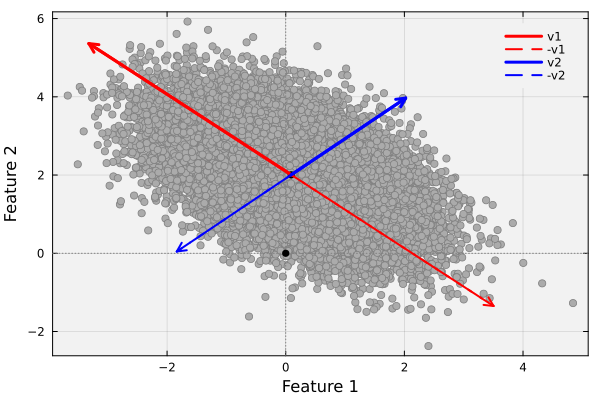

In [13]:
let

    # initialize -
    zscore = 3.91; # z-score for 99.99% confidence interval
    scatter(X[:,1], X[:,2], label="", c=:gray67, msc=:gray50) # plot the data points

    # plot coordinate axes through the origin
    vline!([0.0], color=:gray, lw=1, ls=:dot, label="")
    hline!([0.0], color=:gray, lw=1, ls=:dot, label="")
    scatter!([0], [0], color=:black, ms=4, label="")

    # overlay right singular vectors (same directions as covariance eigenvectors)
    n = size(X, 1)
    lambda = (S .^ 2) ./ (n - 1)
    v1 = V[:, 1]
    v2 = V[:, 2]
    mu = vec(mean(X, dims=1))
    scatter!([mu[1]], [mu[2]], color=:black, ms=4, label="")
    x0, y0 = mu

    # v1 direction
    scale1 = zscore * sqrt(lambda[1])
    x1 = x0 + scale1 * v1[1]
    y1 = y0 + scale1 * v1[2]
    plot!([x0, x1], [y0, y1], arrow=:arrow, lw=3, color=:red, label="v1")
    x2 = x0 - scale1 * v1[1]
    y2 = y0 - scale1 * v1[2]
    plot!([x0, x2], [y0, y2], arrow=:arrow, lw=2, color=:red, ls=:dash, label="-v1")

    # v2 direction
    scale2 = zscore * sqrt(lambda[2])
    x3 = x0 + scale2 * v2[1]
    y3 = y0 + scale2 * v2[2]
    plot!([x0, x3], [y0, y3], arrow=:arrow, lw=3, color=:blue, label="v2")
    x4 = x0 - scale2 * v2[1]
    y4 = y0 - scale2 * v2[2]
    plot!([x0, x4], [y0, y4], arrow=:arrow, lw=2, color=:blue, ls=:dash, label="-v2")

    # background, and labels
    plot!(bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent)
    xlabel!("Feature 1", fontsize=18)
    ylabel!("Feature 2", fontsize=18)
end

___

## Summary
We generated synthetic two-dimensional data, computed its singular value decomposition, and verified the relationship between singular values and covariance matrix eigenvalues.

> __Key Takeaways:__
> 
> * **SVD decomposes data directly for numerical efficiency:** Unlike eigendecomposition approaches that compute the covariance matrix first, SVD operates on the centered data matrix itself, providing superior numerical stability—especially critical for large-scale datasets
> * **Singular values and vectors reveal data geometry:** The singular values quantify variance along principal directions (σ₁/σ₂ indicates data cloud elongation), while the right singular vectors represent the principal axes; visualizing these orthonormal directions shows the intrinsic structure of the data
> * **SVD forms the mathematical foundation for PCA:** By centering data and computing singular values squared (normalized by $n-1$), we obtain both the principal component directions (V) and their explained variances—the core algorithm underlying Principal Component Analysis and dimensionality reduction


These techniques form the foundation for understanding modern dimensionality reduction and data visualization methods.
___